# Multi-class COVID-19 Detection from Chest X-ray Images

**Domain:** Healthcare, Medical Imaging, AI for Diagnostics

**Problem Statement:** Build a multi-class classification model to distinguish between COVID-19, Viral Pneumonia, and Normal chest X-ray images.

**Approach:**
1. Data Exploration & Preprocessing
2. Data Augmentation
3. Baseline CNN Model
4. Transfer Learning (VGG16)
5. Model Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
6. Grad-CAM Explainability
7. Save Model for Deployment

## 1. Install & Import Libraries

In [29]:
# Install required packages (uncomment if needed)
%pip install tensorflow matplotlib seaborn scikit-learn opendatasets pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\VishNiro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.21.0
GPU available: []


## 2. Download & Load Dataset

Using the **COVID-19 Image Dataset** by Pranav Raikokte from Kaggle.

In [31]:
# Dataset already downloaded and extracted to ./data/covid19-image-dataset/
# If not, download from: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
print("Dataset directory ready.")

Dataset directory ready.


In [32]:
# Set dataset paths
BASE_DIR = "./data/covid19-image-dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")

CLASSES = ["Covid", "Normal", "Viral Pneumonia"]

# Verify directory structure
for split in ["train", "test"]:
    split_dir = os.path.join(BASE_DIR, split)
    print(f"\n{split.upper()} set:")
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"  {cls}: {count} images")


TRAIN set:
  Covid: 111 images
  Normal: 70 images
  Viral Pneumonia: 70 images

TEST set:
  Covid: 26 images
  Normal: 20 images
  Viral Pneumonia: 20 images


## 3. Exploratory Data Analysis (EDA)

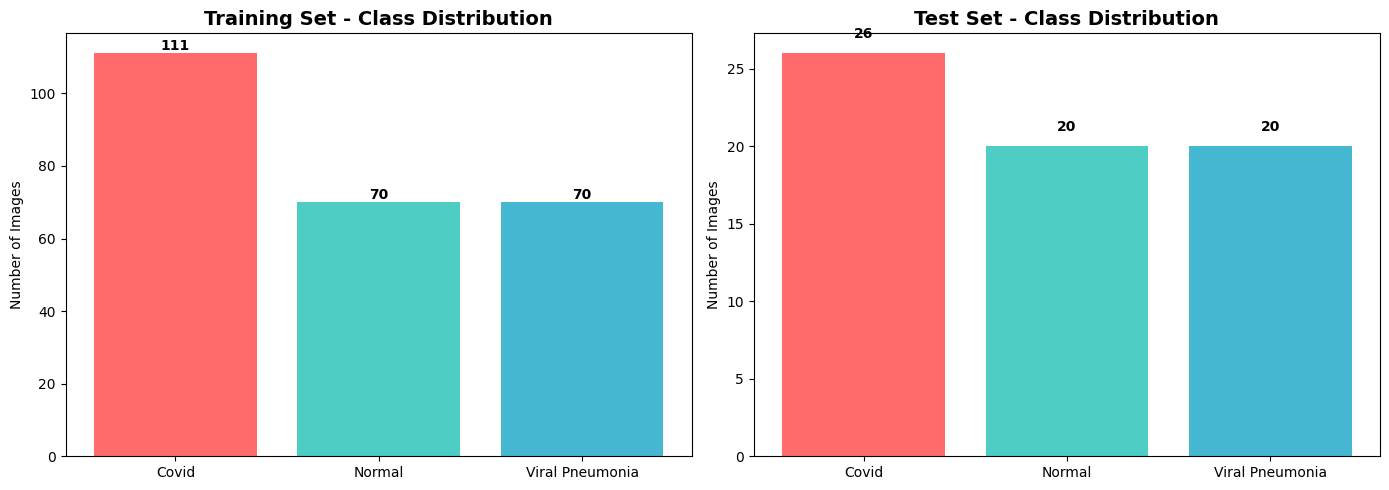


Total training images: 251
Total test images: 66


In [33]:
# Count images per class
train_counts = {}
test_counts = {}

for cls in CLASSES:
    train_path = os.path.join(TRAIN_DIR, cls)
    test_path = os.path.join(TEST_DIR, cls)
    train_counts[cls] = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
    test_counts[cls] = len(os.listdir(test_path)) if os.path.exists(test_path) else 0

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Images')
for i, (cls, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 1, str(count), ha='center', fontweight='bold')

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Images')
for i, (cls, count) in enumerate(test_counts.items()):
    axes[1].text(i, count + 1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal training images: {sum(train_counts.values())}")
print(f"Total test images: {sum(test_counts.values())}")

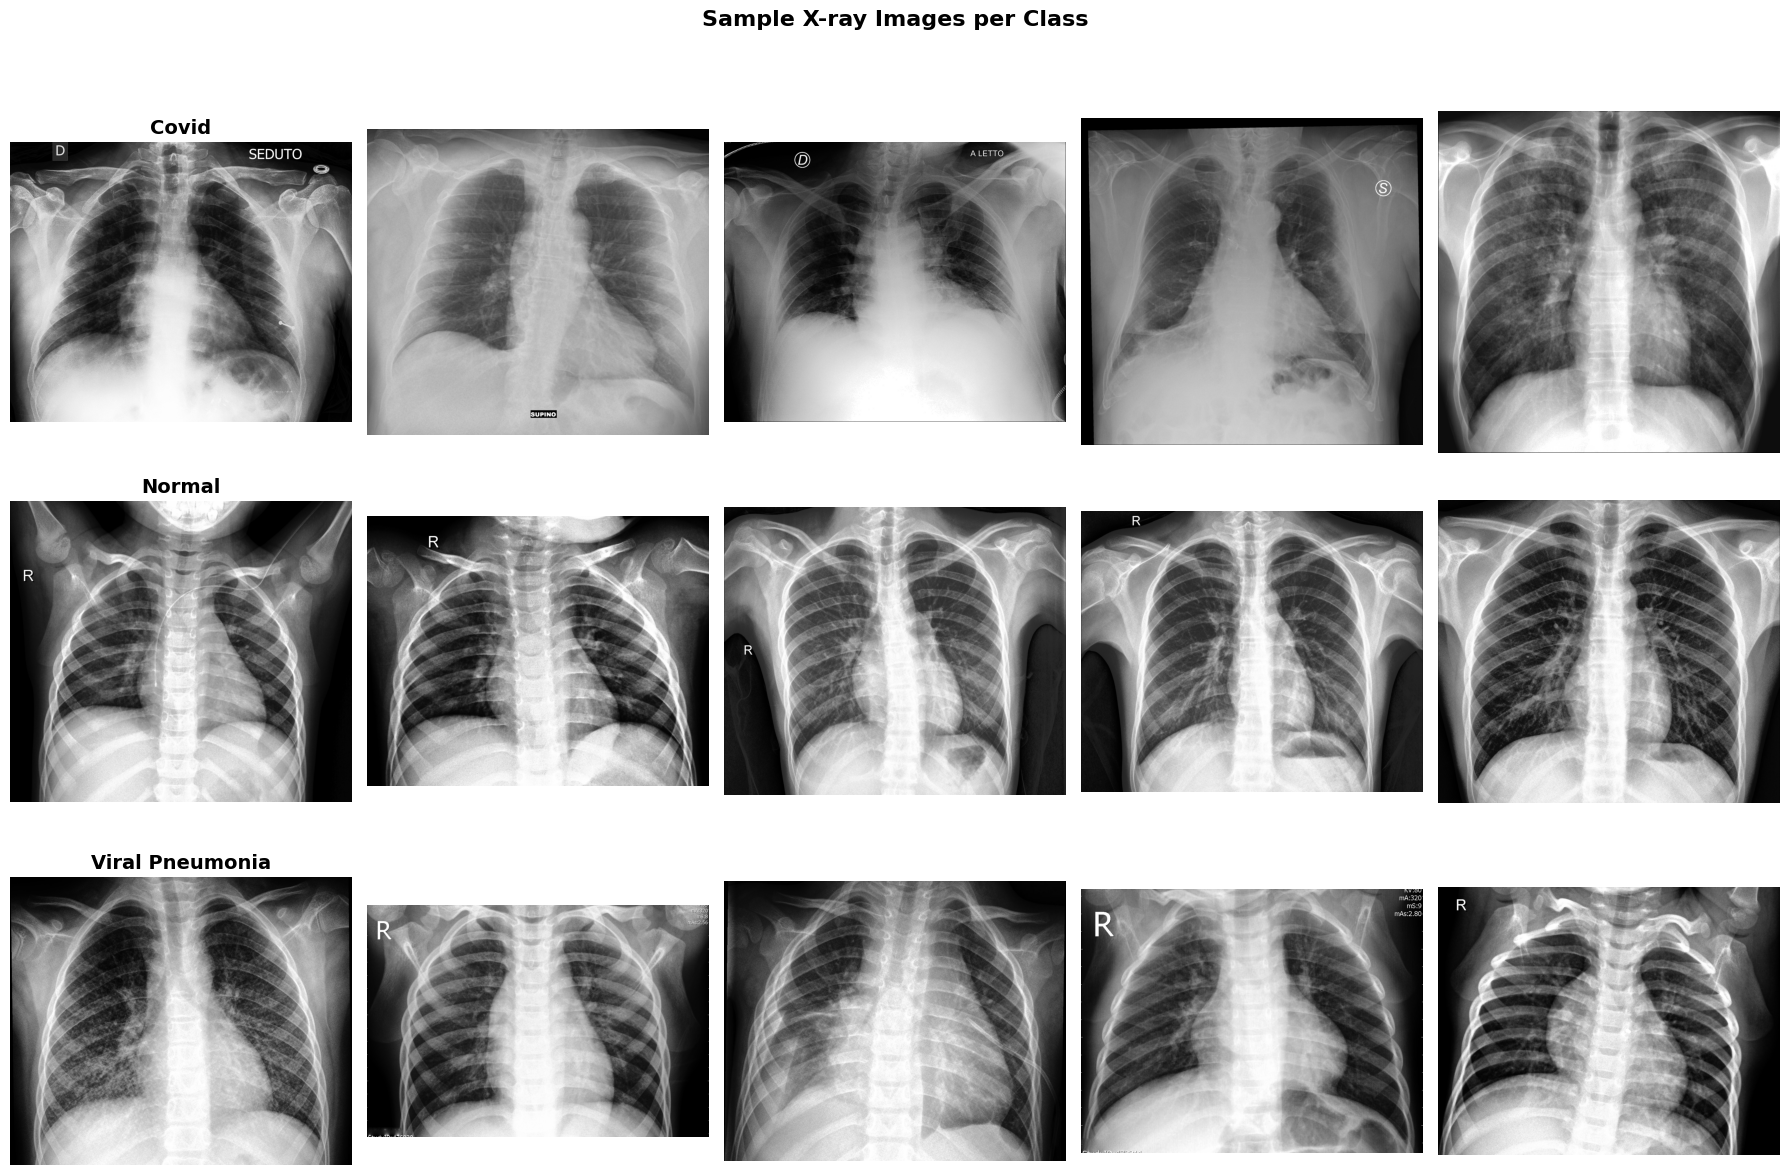

In [34]:
# Display sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(18, 12))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(cls_path)[:5]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'{cls}', fontsize=14, fontweight='bold')

plt.suptitle('Sample X-ray Images per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

Image width  - Min: 439, Max: 4248, Mean: 1718
Image height - Min: 391, Max: 4095, Mean: 1440


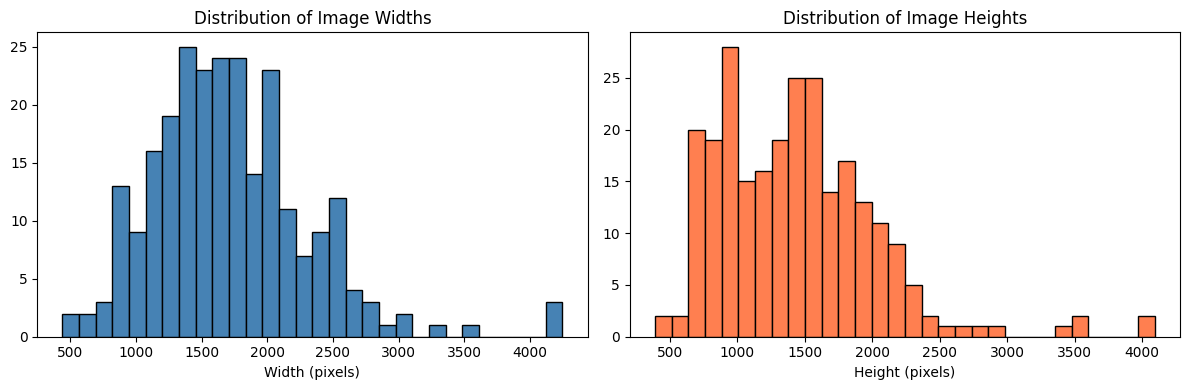

In [35]:
# Analyze image dimensions
widths, heights = [], []
for cls in CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
        except Exception:
            continue

print(f"Image width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"Image height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Image Widths')
axes[0].set_xlabel('Width (pixels)')
axes[1].hist(heights, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Image Heights')
axes[1].set_xlabel('Height (pixels)')
plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Augmentation

In [36]:
# Configuration
IMG_SIZE = (128, 128)  # Reduced from 224 for faster CPU training
BATCH_SIZE = 32
SEED = 42

# Training data generator with augmentation to handle class imbalance
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.15,
    fill_mode='nearest',
    validation_split=0.2  # 80/20 split for train/val
)

# Test data generator - only rescaling, no augmentation
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Training set
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Validation set
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

# Test set
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Class mapping
class_indices = train_generator.class_indices
class_names = {v: k for k, v in class_indices.items()}
NUM_CLASSES = len(class_indices)

print(f"\nClass mapping: {class_indices}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 201 images belonging to 3 classes.
Found 50 images belonging to 3 classes.
Found 66 images belonging to 3 classes.

Class mapping: {'Covid': 0, 'Normal': 1, 'Viral Pneumonia': 2}
Number of classes: 3
Training samples: 201
Validation samples: 50
Test samples: 66


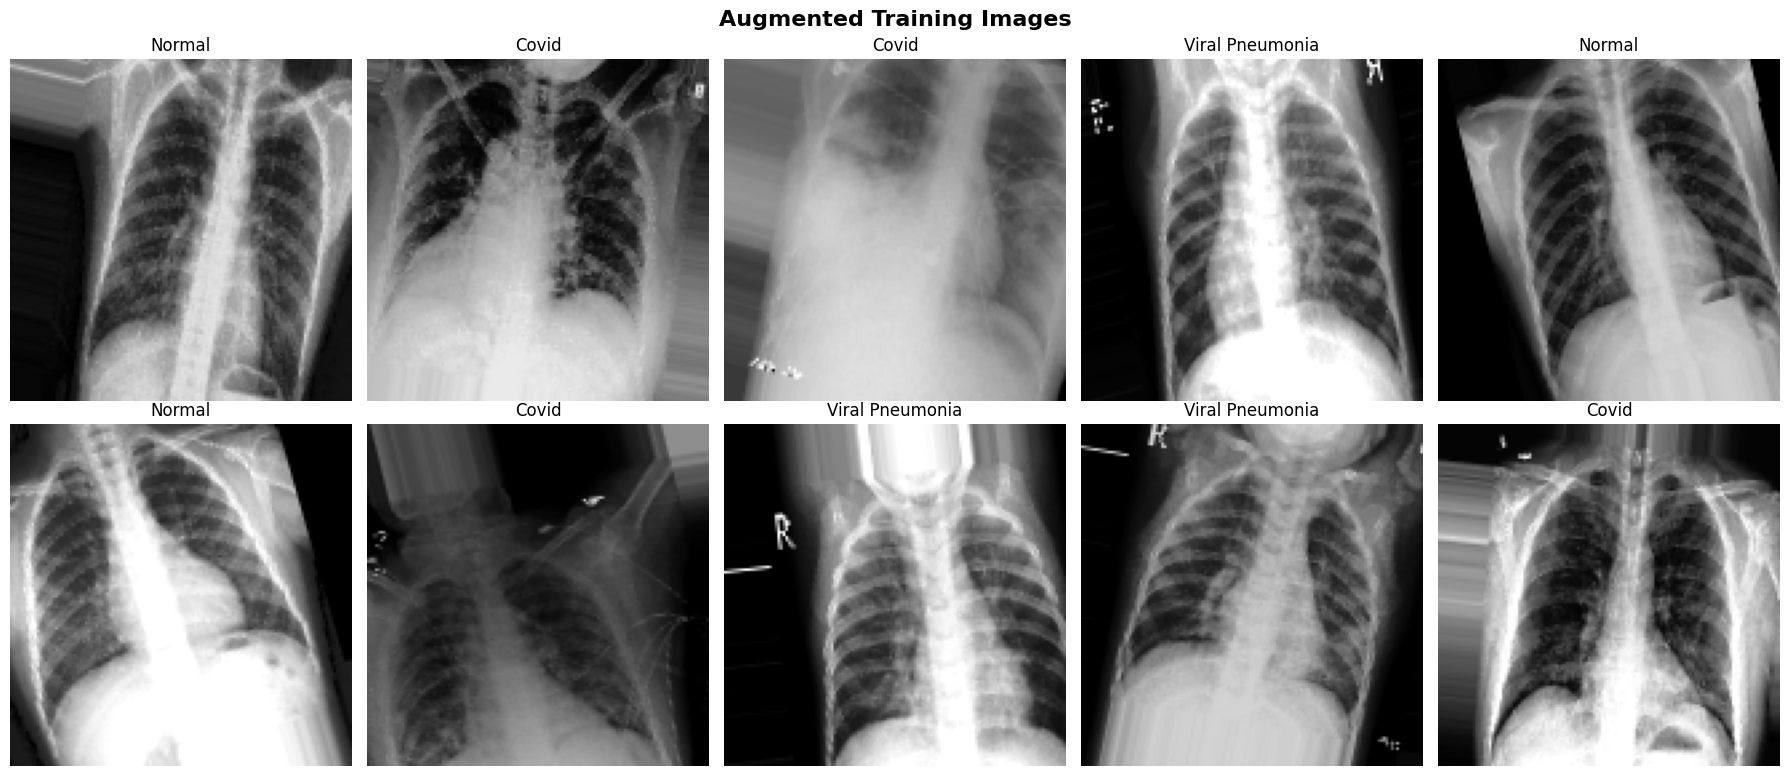

In [37]:
# Visualize augmented images
sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(sample_batch[i])
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx], fontsize=12)
    ax.axis('off')

plt.suptitle('Augmented Training Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Compute Class Weights (Handle Imbalance)

In [38]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))

print("Class weights:")
for idx, weight in class_weights.items():
    print(f"  {class_names[idx]}: {weight:.4f}")

Class weights:
  Covid: 0.7528
  Normal: 1.1964
  Viral Pneumonia: 1.1964


## 6. Model 1: Baseline CNN

In [39]:
def build_baseline_cnn(input_shape, num_classes=3):
    """Build a simple baseline CNN model."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,618,179 (17.62 MB)

 Trainable params: 4,617,219 (17.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [40]:
# Callbacks
baseline_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

# Train baseline CNN
EPOCHS = 15

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=baseline_callbacks
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4826 - loss: 5.8614 - val_accuracy: 0.4400 - val_loss: 1.0790 - learning_rate: 0.0010
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6318 - loss: 5.3587 - val_accuracy: 0.6000 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6667 - loss: 3.3967 - val_accuracy: 0.6400 - val_loss: 0.8247 - learning_rate: 0.0010
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6567 - loss: 3.1592 - val_accuracy: 0.5000 - val_loss: 1.5168 - learning_rate: 0.0010
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6667 - loss: 2.8396 - val_accuracy: 0.4400 - val_loss: 3.2162 - learning_rate: 0.0010
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7214 - loss: 1.7276 - val_accuracy: 0.4400 - val_loss: 6.4913 - learning_rate: 0.0010
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6766 - loss: 2.0132 - val_accuracy: 0.4400 - val_loss:

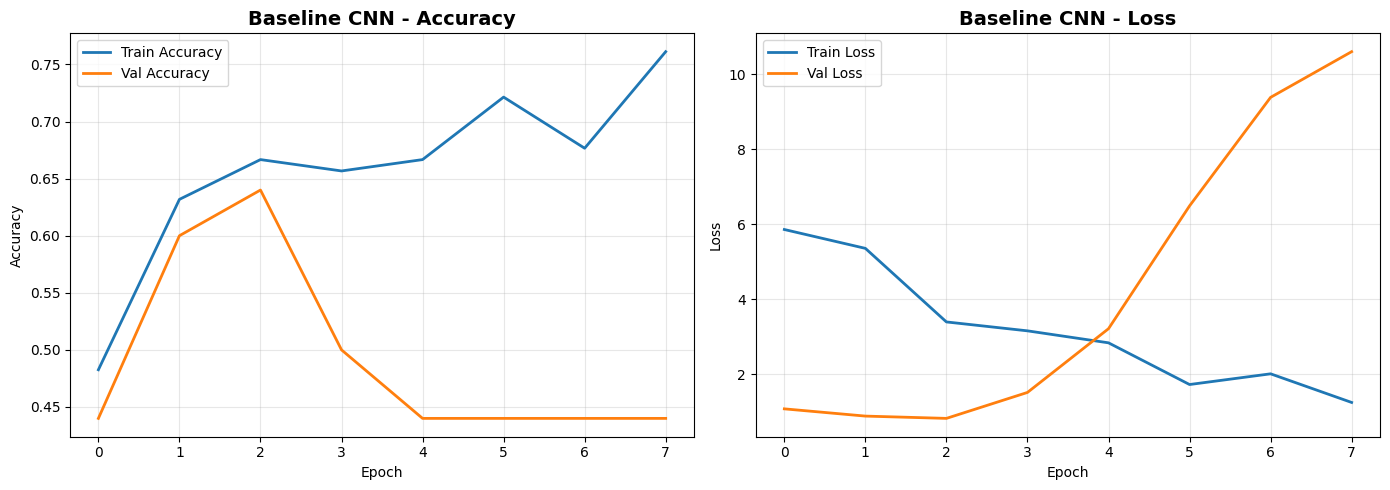

In [41]:
def plot_training_history(history, title="Model"):
    """Plot training & validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'{title} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'{title} - Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(baseline_history, "Baseline CNN")

In [42]:
# Evaluate baseline on test set
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator)
print(f"\nBaseline CNN - Test Accuracy: {baseline_test_acc:.4f}")
print(f"Baseline CNN - Test Loss: {baseline_test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 0.6818 - loss: 0.7740

Baseline CNN - Test Accuracy: 0.6818
Baseline CNN - Test Loss: 0.7740


## 7. Model 2: Transfer Learning with VGG16

In [43]:
def build_vgg16_model(input_shape, num_classes=3):
    """Build a VGG16 transfer learning model."""
    # Load pre-trained VGG16 without top layers
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Build classification head
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

vgg_model, vgg_base = build_vgg16_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

vgg_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,323 (56.76 MB)

 Trainable params: 165,123 (645.01 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [44]:
# Phase 1: Train only the classification head (frozen base)
print("Phase 1: Training classification head (base frozen)...")

vgg_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

phase1_history = vgg_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=vgg_callbacks
)

Phase 1: Training classification head (base frozen)...
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.4478 - loss: 1.2373 - val_accuracy: 0.2800 - val_loss: 1.1052 - learning_rate: 0.0010
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.7114 - loss: 0.6268 - val_accuracy: 0.3600 - val_loss: 0.9980 - learning_rate: 0.0010
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.7811 - loss: 0.5393 - val_accuracy: 0.5400 - val_loss: 0.9381 - learning_rate: 0.0010
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.8458 - loss: 0.4678 - val_accuracy: 0.6200 - val_loss: 0.8883 - learning_rate: 0.0010
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.8358 - loss: 0.4354 - val_accuracy: 0.7000 - val_loss: 0.8437 - learning_rate: 0.0010
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.8209 - loss: 0.4366 - val_accuracy: 0.6600 - val_loss: 0.8267 - learning_rate: 0.0010
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accurac

In [45]:
# Phase 2: Fine-tune the last few layers of VGG16
print("Phase 2: Fine-tuning last convolutional block...")

# Unfreeze the last convolutional block (block5)
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:  # Freeze all except last 4 layers
    layer.trainable = False

# Recompile with lower learning rate for fine-tuning
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print trainable status
trainable = sum(1 for layer in vgg_model.layers[0].layers if layer.trainable)
frozen = sum(1 for layer in vgg_model.layers[0].layers if not layer.trainable)
print(f"Trainable layers: {trainable}, Frozen layers: {frozen}")

fine_tune_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
]

phase2_history = vgg_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Phase 2: Fine-tuning last convolutional block...
Trainable layers: 4, Frozen layers: 15
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8358 - loss: 0.4122 - val_accuracy: 0.7400 - val_loss: 0.6984 - learning_rate: 1.0000e-05
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.9005 - loss: 0.2462 - val_accuracy: 0.7000 - val_loss: 0.6668 - learning_rate: 1.0000e-05
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 4s/step - accuracy: 0.9005 - loss: 0.2166 - val_accuracy: 0.7400 - val_loss: 0.6772 - learning_rate: 1.0000e-05
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8905 - loss: 0.2427 - val_accuracy: 0.7800 - val_loss: 0.6482 - learning_rate: 1.0000e-05
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.9453 - loss: 0.1779 - val_accuracy: 0.7600 - val_loss: 0.6119 - learning_rate: 1.0000e-05
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.9104 - loss: 0.2867 - val_accuracy: 0.7600 - val_loss: 0.5875 - learning_rate: 1.0000e-05


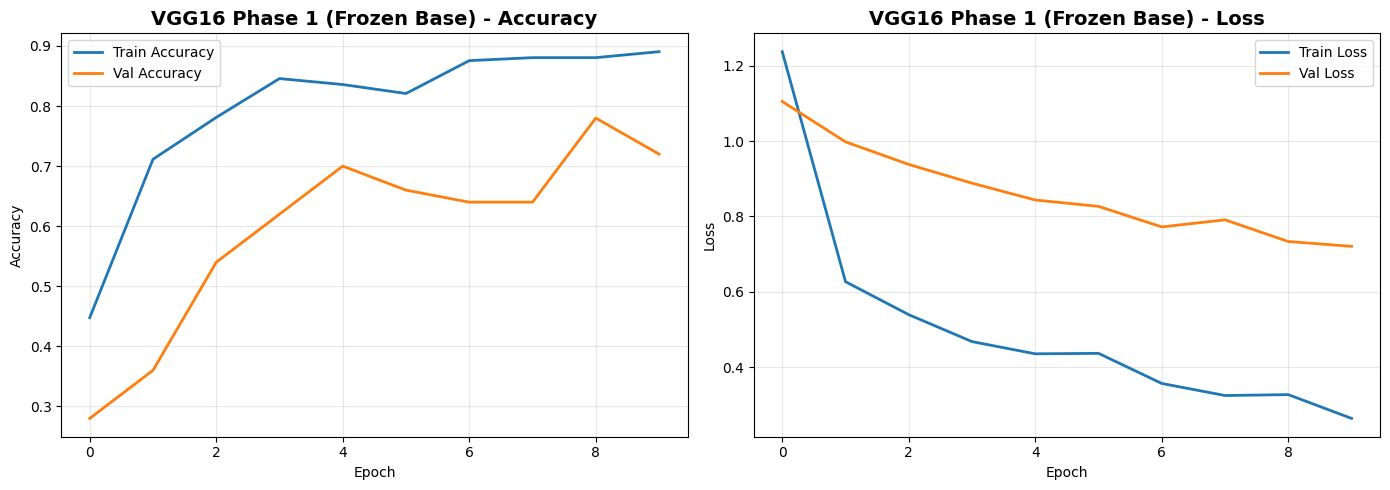

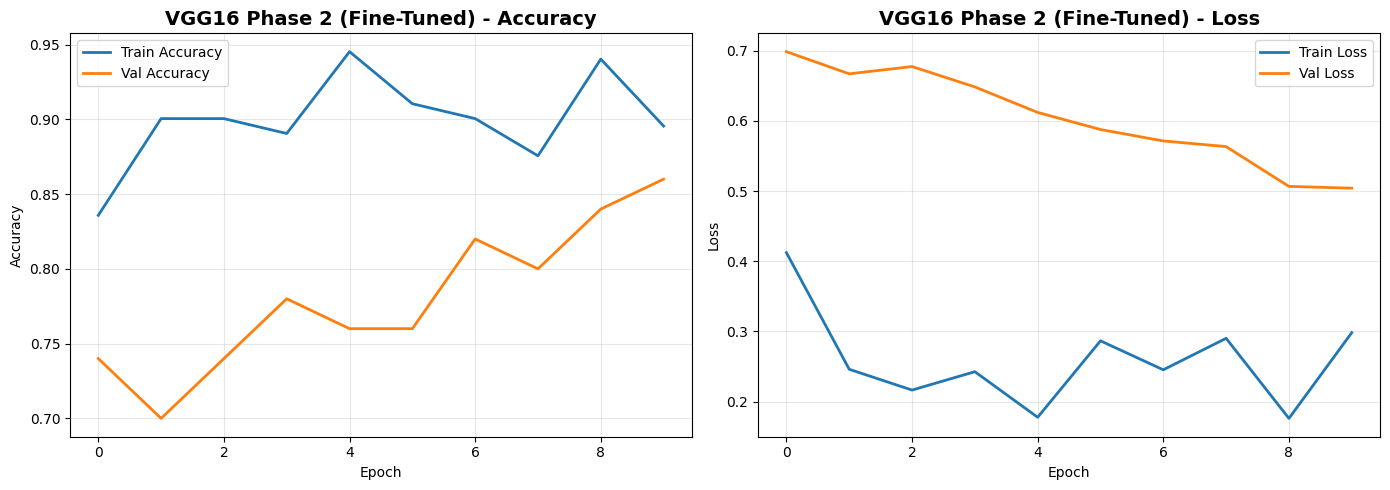

In [46]:
plot_training_history(phase1_history, "VGG16 Phase 1 (Frozen Base)")
plot_training_history(phase2_history, "VGG16 Phase 2 (Fine-Tuned)")

## 8. Comprehensive Model Evaluation

In [47]:
def evaluate_model(model, test_gen, class_names_dict, model_name="Model"):
    """Comprehensive evaluation with metrics, confusion matrix, and ROC curves."""
    
    # Get predictions
    test_gen.reset()
    y_pred_proba = model.predict(test_gen)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_gen.classes
    target_names = [class_names_dict[i] for i in range(len(class_names_dict))]
    
    # Test accuracy
    test_loss, test_acc = model.evaluate(test_gen)
    print(f"\n{'='*60}")
    print(f"{model_name} - Test Results")
    print(f"{'='*60}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    
    # Classification Report
    print(f"\n--- Classification Report ---")
    report = classification_report(y_true, y_pred, target_names=target_names)
    print(report)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ROC-AUC Curves
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    
    plt.figure(figsize=(10, 7))
    colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    
    for i in range(len(target_names)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
                 label=f'{target_names[i]} (AUC = {roc_auc:.4f})')
    
    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, color='navy', linewidth=2, linestyle='--',
             label=f'Micro-average (AUC = {roc_auc_micro:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{model_name} - ROC Curves', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Overall ROC-AUC
    roc_auc_weighted = roc_auc_score(y_true_bin, y_pred_proba, average='weighted', multi_class='ovr')
    print(f"Weighted ROC-AUC: {roc_auc_weighted:.4f}")
    
    return y_pred, y_pred_proba, test_acc


EVALUATING BASELINE CNN
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000021D75B48E00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 292ms/step - accuracy: 0.6818 - loss: 0.7740

Baseline CNN - Test Results
Test Accuracy: 0.6818
Test Loss: 0.7740

--- Classification Report --

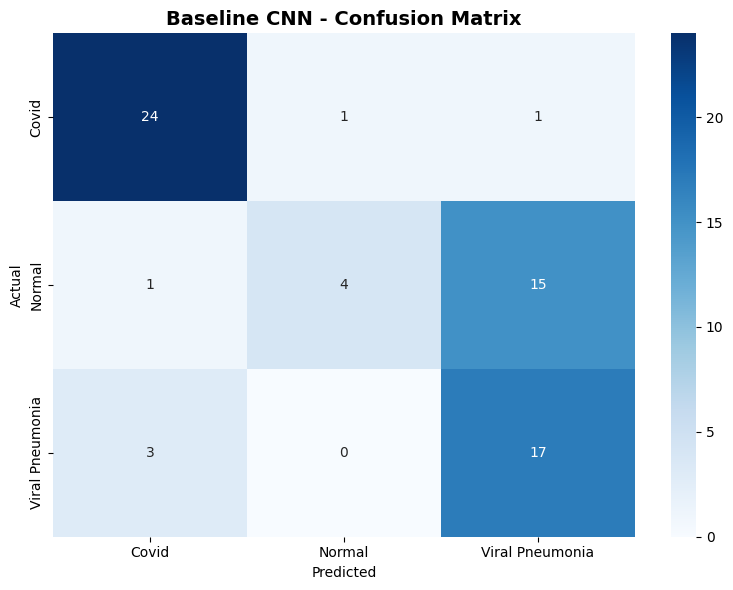

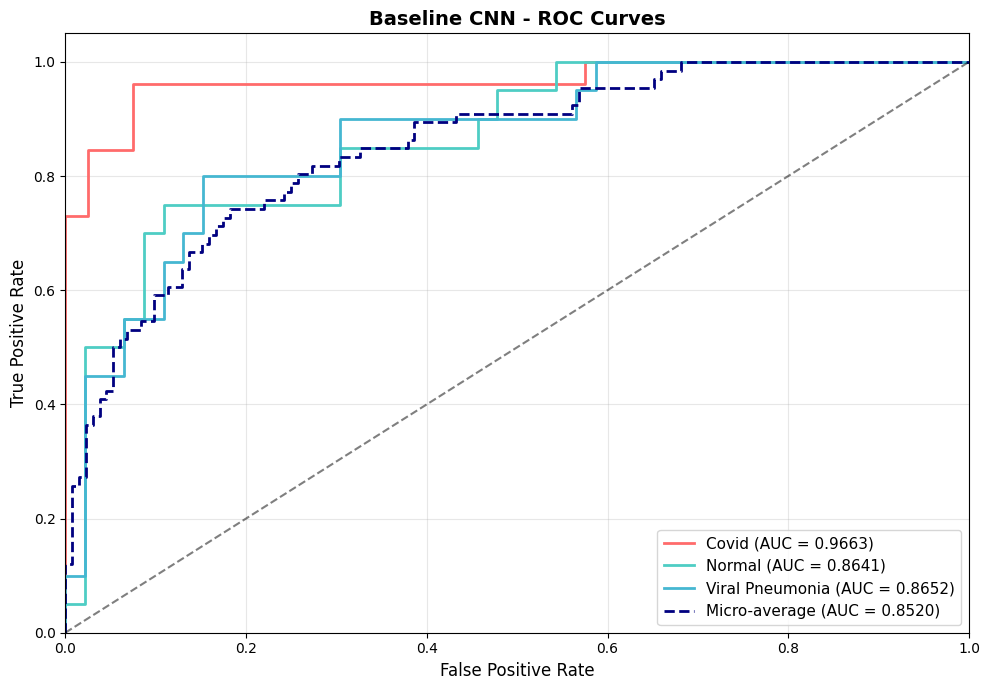

Weighted ROC-AUC: 0.9047


In [48]:
# Evaluate Baseline CNN
print("\n" + "="*60)
print("EVALUATING BASELINE CNN")
print("="*60)
baseline_pred, baseline_proba, baseline_acc = evaluate_model(
    baseline_model, test_generator, class_names, "Baseline CNN"
)


EVALUATING VGG16 TRANSFER LEARNING MODEL
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9394 - loss: 0.3375

VGG16 Transfer Learning - Test Results
Test Accuracy: 0.9394
Test Loss: 0.3375

--- Classification Report ---
                 precision    recall  f1-score   support

          Covid       0.96      1.00      0.98        26
         Normal       0.87      1.00      0.93        20
Viral Pneumonia       1.00      0.80      0.89        20

       accuracy                           0.94        66
      macro avg       0.94      0.93      0.93        66
   weighted avg       0.95      0.94      0.94        66



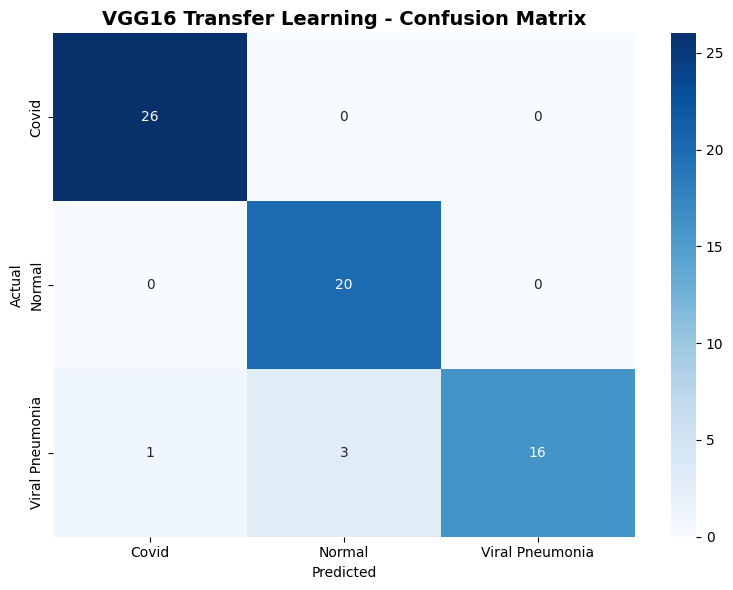

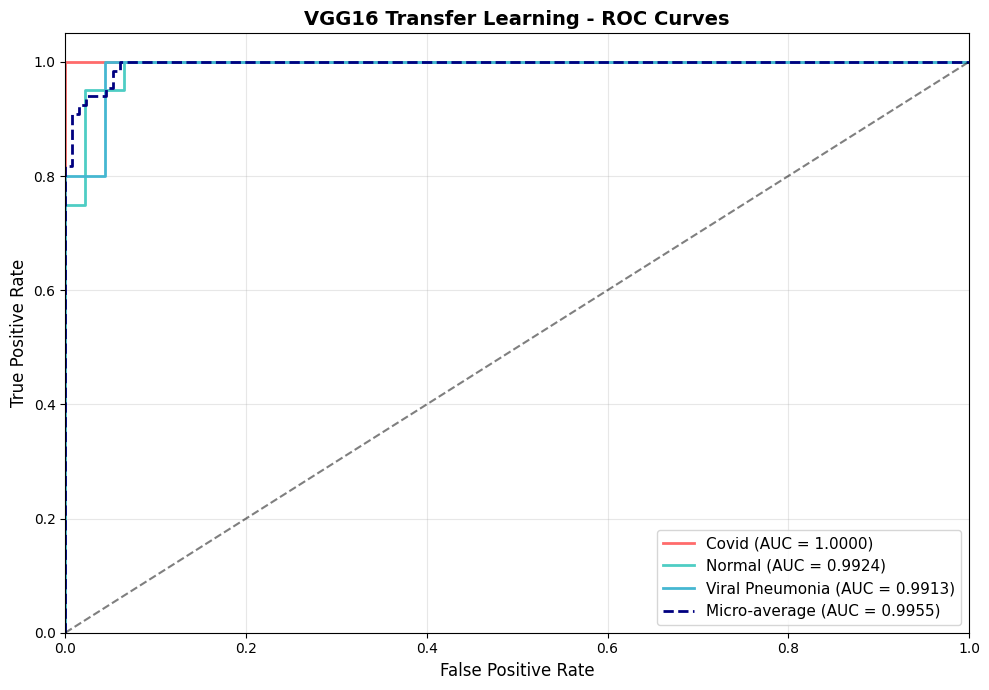

Weighted ROC-AUC: 0.9951


In [49]:
# Evaluate VGG16 Transfer Learning Model
print("\n" + "="*60)
print("EVALUATING VGG16 TRANSFER LEARNING MODEL")
print("="*60)
vgg_pred, vgg_proba, vgg_acc = evaluate_model(
    vgg_model, test_generator, class_names, "VGG16 Transfer Learning"
)

In [50]:
# Model Comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
comparison = pd.DataFrame({
    'Model': ['Baseline CNN', 'VGG16 Transfer Learning'],
    'Test Accuracy': [baseline_acc, vgg_acc]
})
print(comparison.to_string(index=False))

best_model_name = 'VGG16' if vgg_acc > baseline_acc else 'Baseline CNN'
best_model = vgg_model if vgg_acc > baseline_acc else baseline_model
print(f"\nBest Model: {best_model_name}")


MODEL COMPARISON
                  Model  Test Accuracy
           Baseline CNN       0.681818
VGG16 Transfer Learning       0.939394

Best Model: VGG16


## 9. Grad-CAM Explainability

In [51]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    """Generate Grad-CAM heatmap for model explainability."""
    # For models with a nested base (e.g., Sequential wrapping VGG16),
    # use the base model's input to avoid Keras 3 Sequential .input issue
    base = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base = layer
            break

    if base and last_conv_layer_name in [l.name for l in base.layers]:
        # Build grad model through the base model's functional API
        inputs = base.input
        conv_output = base.get_layer(last_conv_layer_name).output
        x = base.output
        for layer in model.layers[1:]:
            x = layer(x)
        grad_model = tf.keras.models.Model(
            inputs=inputs,
            outputs=[conv_output, x]
        )
    else:
        grad_model = tf.keras.models.Model(
            inputs=model.input,
            outputs=[
                model.get_layer(last_conv_layer_name).output,
                model.output
            ]
        )
    
    # Compute gradient of top predicted class w.r.t. the last conv layer output
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        class_output = predictions[:, pred_class]
    
    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    
    return heatmap.numpy(), pred_class.numpy()


def display_gradcam(model, img_path, last_conv_layer_name, class_names_dict, img_size=(224, 224)):
    """Display original image alongside Grad-CAM overlay."""
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_array_expanded = np.expand_dims(img_array, axis=0)
    
    # Get heatmap
    heatmap, pred_class = get_gradcam_heatmap(model, img_array_expanded, last_conv_layer_name)
    
    # Resize heatmap to image size
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_resized = Image.fromarray(heatmap_resized).resize(img_size)
    heatmap_resized = np.array(heatmap_resized)
    
    # Apply colormap
    heatmap_colored = plt.cm.jet(heatmap_resized / 255.0)[:, :, :3]
    
    # Superimpose heatmap on image
    superimposed = (img_array * 0.6 + heatmap_colored * 0.4)
    superimposed = np.clip(superimposed, 0, 1)
    
    # Get prediction probabilities
    pred_proba = model.predict(img_array_expanded, verbose=0)[0]
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original X-ray', fontsize=12)
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title(f'Overlay - Predicted: {class_names_dict[pred_class]}', fontsize=12)
    axes[2].axis('off')
    
    # Add prediction probabilities as text
    prob_text = '\n'.join([f'{class_names_dict[i]}: {pred_proba[i]:.2%}' for i in range(len(class_names_dict))])
    fig.text(0.98, 0.5, prob_text, fontsize=11, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('Grad-CAM Explainability', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return pred_class, pred_proba

In [52]:
# Find the last convolutional layer name for VGG16-based model
# For VGG16 Sequential model, we access the base model's last conv layer

# Build a functional model for Grad-CAM compatibility
vgg_base_for_gradcam = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# Create functional model
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = vgg_base_for_gradcam(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

gradcam_model = keras.Model(inputs=inputs, outputs=outputs)

# Copy weights from the trained VGG model
gradcam_model.set_weights(vgg_model.get_weights())

# Get the last conv layer name
last_conv_layer = None
for layer in gradcam_model.layers:
    if isinstance(layer, tf.keras.Model):
        for sub_layer in layer.layers:
            if 'conv' in sub_layer.name:
                last_conv_layer = layer.name  # Use the VGG16 model layer name

# Alternative: use the VGG16 block5_conv3 directly
last_conv_layer_name = vgg_base_for_gradcam.name
print(f"Using layer for Grad-CAM: {last_conv_layer_name}")

Using layer for Grad-CAM: vgg16


In [53]:
# Alternative simpler Grad-CAM that works with Sequential models
def gradcam_sequential(model, img_path, img_size=IMG_SIZE):
    """Grad-CAM for Sequential VGG16 model."""
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)
    
    # Get the VGG16 base model (first layer of Sequential)
    base = model.layers[0]
    
    # Find last conv layer in base model
    last_conv = None
    for layer in base.layers:
        if 'conv' in layer.name:
            last_conv = layer.name
    
    # Build grad model using the base model's input (Functional API)
    # This avoids the "Sequential has no defined input" error in Keras 3
    inputs = base.input
    conv_output = base.get_layer(last_conv).output
    x = base.output
    for layer in model.layers[1:]:
        x = layer(x)
    
    grad_model = tf.keras.models.Model(
        inputs=inputs,
        outputs=[conv_output, x]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_input)
        pred_idx = tf.argmax(predictions[0])
        class_output = predictions[:, pred_idx]
    
    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    
    # Resize and overlay
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_resized = np.array(Image.fromarray(heatmap_uint8).resize(img_size))
    heatmap_colored = plt.cm.jet(heatmap_resized / 255.0)[:, :, :3]
    superimposed = np.clip(img_array * 0.6 + heatmap_colored * 0.4, 0, 1)
    
    pred_proba = predictions[0].numpy()
    pred_class = pred_idx.numpy()
    
    return img_array, heatmap_resized, superimposed, pred_class, pred_proba

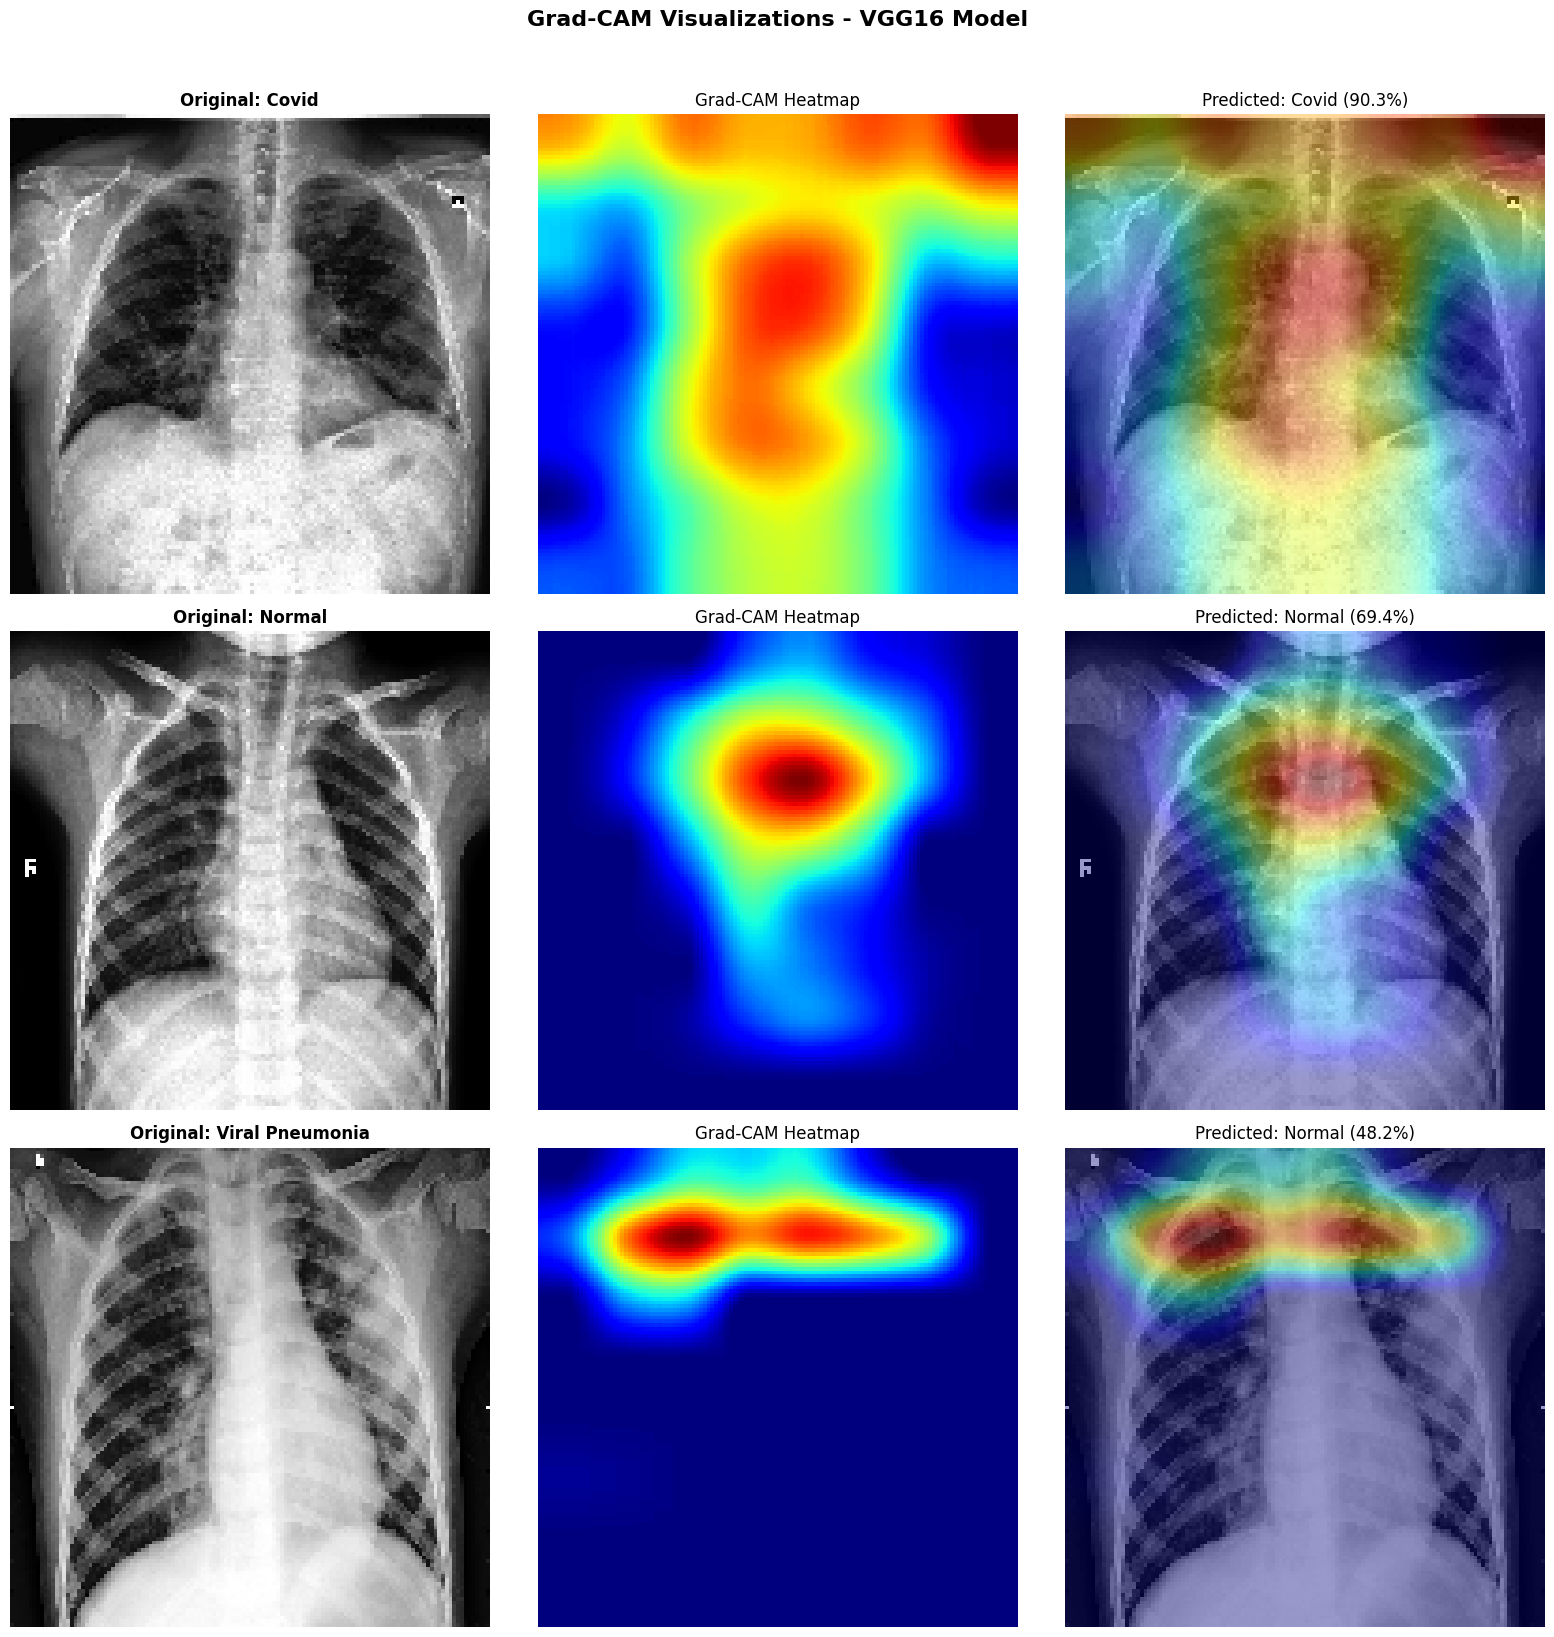

In [54]:
# Apply Grad-CAM on sample test images (one from each class)
fig, axes = plt.subplots(3, 3, figsize=(16, 16))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TEST_DIR, cls)
    sample_img = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, sample_img)
    
    original, heatmap, overlay, pred_cls, pred_prob = gradcam_sequential(
        vgg_model, img_path
    )
    
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'Original: {cls}', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(overlay)
    pred_label = class_names[pred_cls]
    confidence = pred_prob[pred_cls]
    axes[row, 2].set_title(f'Predicted: {pred_label} ({confidence:.1%})', fontsize=12)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM Visualizations - VGG16 Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualize Misclassified Images

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Total misclassified images: 4 out of 66


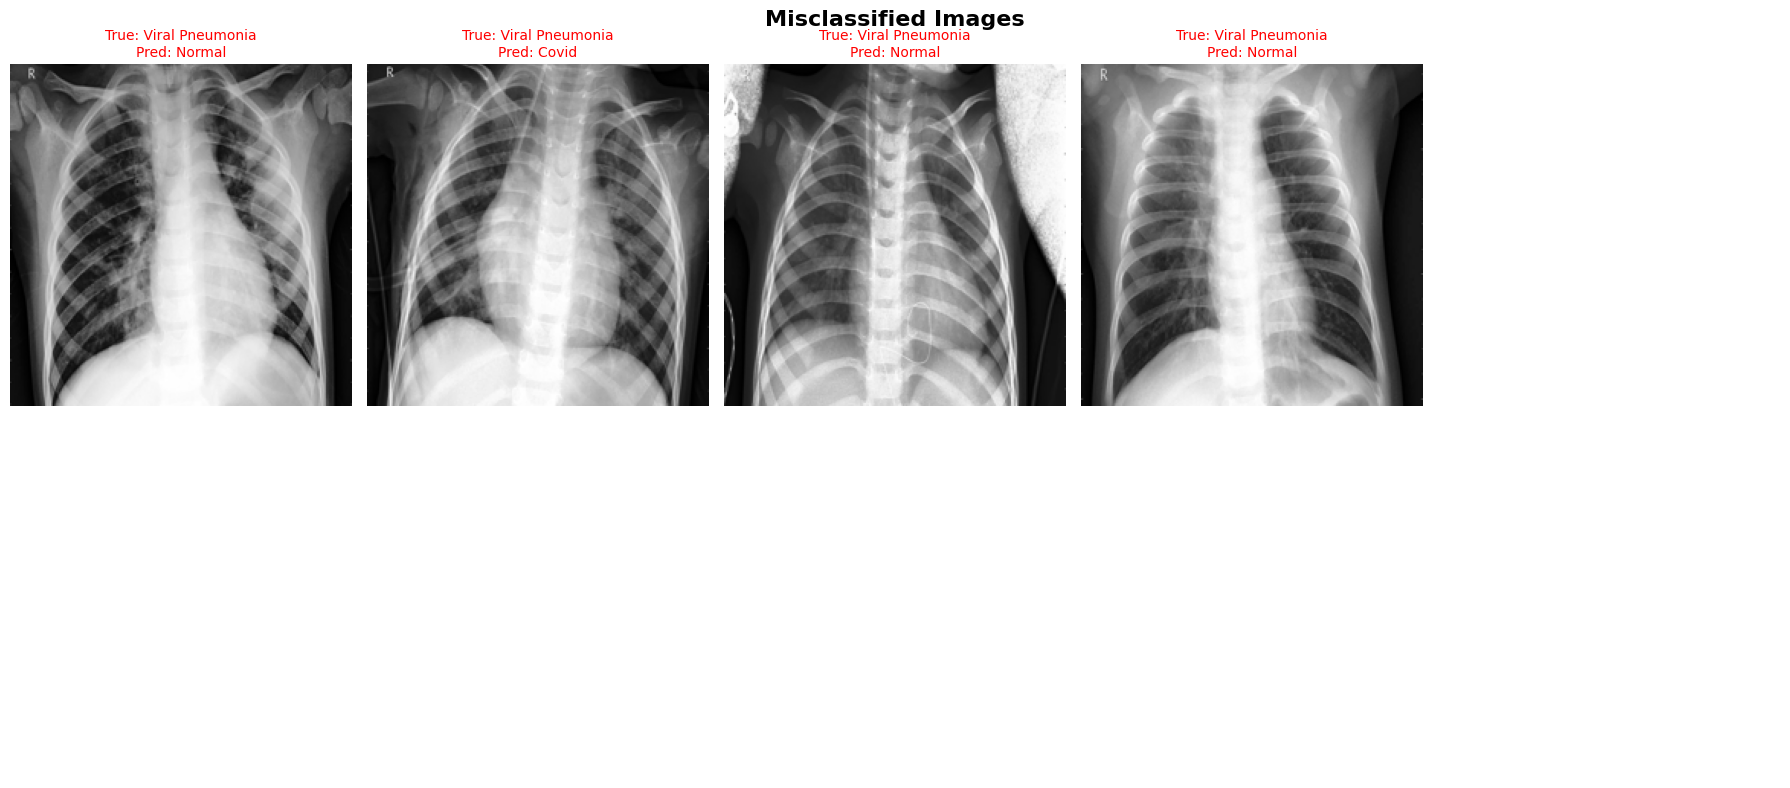

In [55]:
# Find misclassified images
test_generator.reset()
y_true_test = test_generator.classes
y_pred_test = np.argmax(vgg_model.predict(test_generator), axis=1)

misclassified_idx = np.where(y_true_test != y_pred_test)[0]
print(f"Total misclassified images: {len(misclassified_idx)} out of {len(y_true_test)}")

# Display misclassified images
num_show = min(10, len(misclassified_idx))
if num_show > 0:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    file_paths = test_generator.filepaths
    
    for i in range(num_show):
        idx = misclassified_idx[i]
        img = Image.open(file_paths[idx]).convert('RGB').resize((224, 224))
        ax = axes[i // 5, i % 5]
        ax.imshow(img)
        true_label = class_names[y_true_test[idx]]
        pred_label = class_names[y_pred_test[idx]]
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10, color='red')
        ax.axis('off')
    
    # Hide empty subplots
    for i in range(num_show, 10):
        axes[i // 5, i % 5].axis('off')
    
    plt.suptitle('Misclassified Images', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('misclassified_images.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No misclassified images! Perfect accuracy.")

## 11. Save the Best Model for Deployment

In [56]:
# Save the best model
MODEL_SAVE_PATH = "covid19_xray_model.keras"

best_model.save(MODEL_SAVE_PATH)
print(f"Best model ({best_model_name}) saved to: {MODEL_SAVE_PATH}")

# Save class names mapping
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print("Class names saved to: class_names.json")

# Verify saved model
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
loaded_loss, loaded_acc = loaded_model.evaluate(test_generator)
print(f"\nLoaded model test accuracy: {loaded_acc:.4f} (should match above)")

Best model (VGG16) saved to: covid19_xray_model.keras
Class names saved to: class_names.json
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9394 - loss: 0.3375

Loaded model test accuracy: 0.9394 (should match above)


## 12. Summary & Conclusions

### Key Findings:
1. **Data**: The dataset has 3 classes (Covid, Normal, Viral Pneumonia) with class imbalance handled via augmentation and class weights.
2. **Baseline CNN**: Provides a starting point for comparison.
3. **VGG16 Transfer Learning**: Significantly outperforms baseline by leveraging ImageNet pre-trained features.
4. **Fine-tuning**: Unfreezing the last conv block further improves performance.
5. **Grad-CAM**: Shows the model focuses on lung regions (opacities, ground-glass patterns) for COVID-19 detection.

### Next Steps:
- Deploy using the Streamlit web app (`streamlit_app.py`)
- Try other architectures (ResNet-50, DenseNet) for comparison
- Collect more COVID-19 images to improve generalization